# Рубежный контроль №1. Тема: Технологии разведочного анализа и обработки данных.
# Вариант 10. Кожевникова Мария. ИБМ3-65Б

## Задача №2, 
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?
## Датасет №2
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine


# Импорт библиотек

In [131]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from IPython.display import Image
%matplotlib inline 
sns.set(style="ticks")
from sklearn.datasets import load_wine

# Загрузка данных

In [132]:
def make_dataframe(ds_function):
    ds = ds_function()
    df = pd.DataFrame(data= np.c_[ds['data'], ds['target']],
                     columns= list(ds['feature_names']) + ['target'])
    return df

In [133]:
# 
data = make_dataframe(load_wine)
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0


# Основные характеристики датасета

In [134]:
# Размер датасета
data.shape

(178, 14)

In [135]:
# Список колонок
data.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [136]:
# Список колонок с типами данных
data.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                          float64
dtype: object

In [137]:
# Закодируем категориальный признак обратно - из Target в Class
# Create a mapping dictionary
class_map = {0: 'Class_1', 1: 'Class_2', 2: 'Class_3'}

data['Class'] = data['target'].map(class_map)


In [138]:
data.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                          float64
Class                            object
dtype: object

# Внедрение пропусков данных

In [139]:
# посчитаем пропуски
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

alcohol - 0
malic_acid - 0
ash - 0
alcalinity_of_ash - 0
magnesium - 0
total_phenols - 0
flavanoids - 0
nonflavanoid_phenols - 0
proanthocyanins - 0
color_intensity - 0
hue - 0
od280/od315_of_diluted_wines - 0
proline - 0
target - 0
Class - 0


In [140]:
# Пропусков в датасете нет
# Внедрим пропуски искусственно в колонку alcohol и Class
random_indices = data.sample(n=10).index
data.loc[random_indices, 'Class'] = np.nan
random_indices1 = data.sample(n=10).index
data.loc[random_indices1, 'alcohol'] = np.nan

In [141]:
# посчитаем пропуски
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

alcohol - 10
malic_acid - 0
ash - 0
alcalinity_of_ash - 0
magnesium - 0
total_phenols - 0
flavanoids - 0
nonflavanoid_phenols - 0
proanthocyanins - 0
color_intensity - 0
hue - 0
od280/od315_of_diluted_wines - 0
proline - 0
target - 0
Class - 10


# Восстановление пропусков

## Количественный признак - колонка alcohol

In [142]:
strategies=['mean', 'median', 'most_frequent']

In [143]:
# функция, которая позволяет задавать колонку и вид импьютации
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

In [144]:
# mean
data_mean = data
test_num_impute_col(data_mean, 'alcohol', strategies[0])

('alcohol',
 'mean',
 10,
 np.float64(13.013452380952382),
 np.float64(13.013452380952382))

In [145]:
# median
data_median = data
test_num_impute_col(data_median, 'alcohol', strategies[1])

('alcohol', 'median', 10, np.float64(13.05), np.float64(13.05))

In [146]:
# most frequent
data_mf = data
test_num_impute_col(data_mf, 'alcohol', strategies[2])

('alcohol', 'most_frequent', 10, np.float64(13.05), np.float64(13.05))

## Категоральный признак - Class 

In [153]:
cat_temp_data = data[['Class']]
cat_temp_data

,Class
0,Class_1
1,Class_1
2,Class_1
3,Class_1
4,Class_1
...,...
173,Class_3
174,Class_3
175,Class_3
176,Class_3


In [148]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2

array([['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_2'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_2'],
       ['Class_2'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_2'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],


In [149]:
# Импьютация константой
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Class_3')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3

array([['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_3'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_3'],
       ['Class_3'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_3'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],
       ['Class_1'],


# Визуальное исследование датасета

## [Гистограмма]


<Axes: xlabel='alcohol', ylabel='Count'>

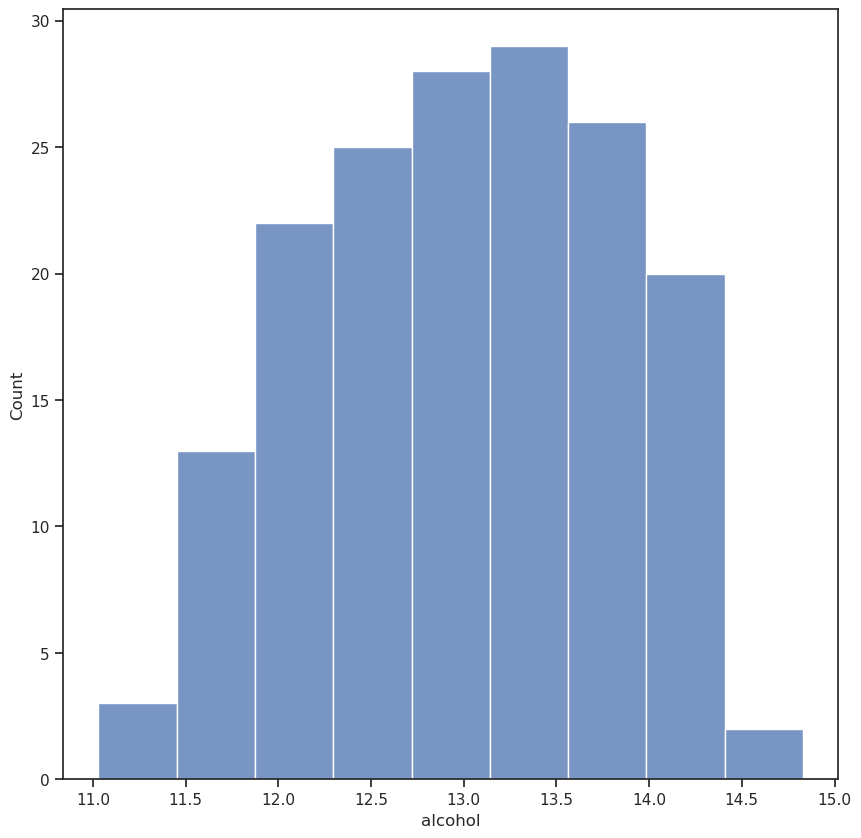

In [150]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.histplot(data['alcohol'])